In [1]:
try:
    import anndata
    import scanpy
except ImportError:
    print("Instalando dependências compatíveis com o ambiente do Colab...")
    # Mantém o pandas travado na versão esperada pelo Colab (2.2.3)
    !pip install -q "pandas==2.2.3" anndata scanpy

In [2]:
!git push origin Teste_sem_binarização_dados_brutos

fatal: not a git repository (or any of the parent directories): .git


In [3]:
import os
import sys

REPO_NAME = "pipiline_hopifield"  # Nome do seu repo
REPO_URL = "https://github.com/letdevx/pipiline_hopifield.git"
DEST_PATH = f"/content/{REPO_NAME}"

# Clona ou atualiza o código na VM
if not os.path.exists(DEST_PATH):
    print("Clonando código para a VM...")
    !git clone {REPO_URL} {DEST_PATH}
else:
    print("Atualizando código na VM...")
    !cd {DEST_PATH} && git pull

!cd {DEST_PATH} && git checkout Teste_sem_binarização_dados_brutos

# Adiciona a pasta 'src' da VM ao path do Python
SRC_PATH = os.path.join(DEST_PATH, "src")
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

Atualizando código na VM...
Already up to date.
Already on 'Teste_sem_binarização_dados_brutos'
Your branch is up to date with 'origin/Teste_sem_binarização_dados_brutos'.


In [4]:
try:
    from google.colab import drive
    if not os.path.exists('/content/drive'):
        print("[Colab] Montando Google Drive em /content/drive...")
        drive.mount('/content/drive')
except (ImportError, Exception):
    pass

DRIVE_INPUTS = '/content/drive/Othercomputers/Meu laptop/Documents/Letworkspace/Teste hop/imputs'
!ls "{DRIVE_INPUTS}"

Mounted at /content/drive
celltypeBinF_eceltypename.csv  matrizFiltradaeNormalizadaF.h5ad
cell_types_binarioF.txt        pan_anotado.h5ad
featuresM.tsv.gz	       PanNumerico.csv
featuresPANcorrigido.tsv       requirements.txt
features.tsv		       script01_analises_preliminares.ipynb
matriz_anotada_finalM.h5ad     tipos_celulares_numericoMs.txt


In [5]:
!cd /content/pipiline_hopifield && git pull

Already up to date.


In [6]:
import importlib
import config
importlib.reload(config)

<module 'config' from '/content/pipiline_hopifield/src/config.py'>

In [7]:
try:
    %load_ext autoreload
    %autoreload 2
except Exception:
    pass

import sys, os

import importlib
import numpy as np
import pandas as pd
import torch
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, classification_report

# Detecção robusta do diretório raiz e de src/ para Jupyter, Scripts e Colab
if '__file__' in globals():
    ROOT_DIR = os.path.dirname(os.path.abspath(__file__))
else:
    ROOT_DIR = os.path.abspath(os.getcwd())
    if not os.path.exists(os.path.join(ROOT_DIR, 'src')) and os.path.exists(os.path.join(os.path.dirname(ROOT_DIR), 'src')):
        ROOT_DIR = os.path.dirname(ROOT_DIR)

SRC_DIR = os.path.join(ROOT_DIR, 'src')
for p in (ROOT_DIR, SRC_DIR):
    if p not in sys.path:
        sys.path.insert(0, p)

import config
importlib.reload(config)
from config import (
    PATH_REFERENCIA, PATH_ALVO, PATH_FEATURES_REFERENCIA, PATH_FEATURES_ALVO,
    PATH_SWEEP_REFERENCIA, PATH_SWEEP_ALVO, PATH_LABELS_REFERENCIA, PATH_LABELS_ALVO,
    OUT_BINARIZACAO, OUT_ALINHAMENTO, OUT_TOP_GENES,
    OUT_TREINAMENTO, OUT_HOPFIELD, OUT_RELATORIO,
)

import alinhamento
importlib.reload(alinhamento)

from preprocessing import Binarizador
from alinhamento import (
    LeitorFeatures, AnalisadorSobreposicao, Alinhador, AlinhadorEsparso,
    ValidadorAlinhamento, ValidadorFeatures, SelecionadorGenesFrequentes, AnalisadorCobertura,
)
from treinamento import (
    GeradorConjuntoTreinamento, CarregadorDadosFujita,
    ProjetorSWeP, ProjetorSWeePR,
    ExtratorPadroesSubcluster, ModernHopfieldNetwork, AvaliadorHopfield,
    GeradorRelatorio,
)
from treinamento.hopfield_utils import wsort, closervects


SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device('cuda')
    torch.cuda.manual_seed_all(SEED)
    # Garante determinismo em operações CUDA (útil para reprodutibilidade)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f'Dispositivo: {device} ({torch.cuda.get_device_name(0)})')
    print(f'VRAM disponível: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')
else:
    device = torch.device('cpu')
    print(f'Dispositivo: {device} (GPU não disponível)')



Dispositivo: cuda (NVIDIA A100-SXM4-40GB)
VRAM disponível: 42.41 GB



#### 2. Binarização
 Converte as matrizes de expressão `.h5ad` para formato binário (valores > 0 → 1, zeros → 0). O `Binarizador` detecta automaticamente se o arquivo já existe e pula o processamento nesse caso.

In [8]:
binarizador_ref = Binarizador(path_h5ad=PATH_REFERENCIA, out_dir=OUT_BINARIZACAO)
binarizador_alvo = Binarizador(path_h5ad=PATH_ALVO, out_dir=OUT_BINARIZACAO)

binarizador_ref.binarizar()
binarizador_alvo.binarizar()

print('Referência binarizada em:', binarizador_ref.path_binarizada)
print('Alvo binarizado em:', binarizador_alvo.path_binarizada)

[Binarizador] Carregando arquivo h5ad...
[Binarizador] Shape da matriz: (58326, 61541)
[Binarizador] Binarizando a matriz...
[Binarizador] Salvando arquivo h5ad binarizado...
[Binarizador] Arquivo salvo: /content/pipiline_hopifield/outputs/binarizacao/pan_anotado/matrizBinarizadaM.h5ad
[Binarizador] Carregando arquivo h5ad...
[Binarizador] Shape da matriz: (47523, 32738)
[Binarizador] Binarizando a matriz...
[Binarizador] Salvando arquivo h5ad binarizado...
[Binarizador] Arquivo salvo: /content/pipiline_hopifield/outputs/binarizacao/matriz_anotada_finalM/matrizBinarizadaM.h5ad
Referência binarizada em: /content/pipiline_hopifield/outputs/binarizacao/pan_anotado/matrizBinarizadaM.h5ad
Alvo binarizado em: /content/pipiline_hopifield/outputs/binarizacao/matriz_anotada_finalM/matrizBinarizadaM.h5ad


#### 3. Alinhamento de espaços gênicos ↔️
 Os dois datasets têm espaços gênicos distintos (36 591 genes no Fujita, 32 643 no Mathys, ~30 312 em comum). 
 O alinhamento:
 1. Lê os mapeamentos `gene_name → Ensembl ID` de cada dataset.
 2. Valida a integridade dos arquivos de features e a compatibilidade com as matrizes AnnData.
 3. Define a ordem canônica dos genes baseada no Fujita (referência).
 4. Realinha ambas as matrizes para esse espaço canônico.
    - Genes ausentes no **Mathys** são preenchidos com `0.5` como sentinela.
 5. Valida que as duas matrizes resultantes têm genes na mesma ordem.

In [9]:
# Passo 1 — Leitura dos arquivos de features
leitor = LeitorFeatures(PATH_FEATURES_REFERENCIA, PATH_FEATURES_ALVO)
leitor.ler()
print(leitor)

[LeitorFeatures] Referência : 61541 genes mapeados
[LeitorFeatures] Alvo       : 32738 genes mapeados
LeitorFeatures(
  path_features_referencia = /content/drive/Othercomputers/Meu laptop/Documents/Letworkspace/Teste hop/imputs/featuresPANcorrigido.tsv
  path_features_alvo       = /content/drive/Othercomputers/Meu laptop/Documents/Letworkspace/Teste hop/imputs/featuresM.tsv.gz
  map_referencia           = 61541 genes
  map_alvo                 = 32738 genes
)


In [ ]:
# Passo 1.5 — Validação Prévia de Compatibilidade e Ordem de Colunas (Fail-Fast)
validador_feat = ValidadorFeatures(min_match_pct=50.0, min_genes_comuns=1000)
validador_feat.validar_tudo(
    path_features_ref=PATH_FEATURES_REFERENCIA,
    path_features_alvo=PATH_FEATURES_ALVO,
    path_h5ad_ref=binarizador_ref.path_binarizada,
    path_h5ad_alvo=binarizador_alvo.path_binarizada,
    map_f=leitor.map_f,
    map_m=leitor.map_m,
)

In [10]:
# Passo 2 — Análise de sobreposição dos espaços gênicos
# var_names idênticos no original e no binarizado — lemos direto do original
_f = ad.read_h5ad(PATH_REFERENCIA, backed='r')
var_names_f_original = _f.var_names.tolist()
_f.file.close()
del _f

analisador = AnalisadorSobreposicao(leitor.map_f, leitor.map_m, var_names_f_original)
analisador.analisar()
print(analisador)

[AnalisadorSobreposicao] Em comum  : 30836
[AnalisadorSobreposicao] Só Fujita : 30705
[AnalisadorSobreposicao] Só Mathys : 1902  <- serão excluídos
[AnalisadorSobreposicao] Espaço gênico final: 61541 genes
AnalisadorSobreposicao(
  ids_comuns      = 30836
  ids_so_f        = 30705
  ids_so_m        = 1902
  genes_ordenados = 61541
)


In [11]:
# Passo 3 — Alinhamento dos dois h5ad binarizados (100% Esparso & OOM-Safe)
alinhador = AlinhadorEsparso(
    path_binarizada_m = binarizador_alvo.path_binarizada,
    path_binarizada_f = binarizador_ref.path_binarizada,
    out_dir           = OUT_ALINHAMENTO,
    map_f             = leitor.map_f,
    map_m             = leitor.map_m,
    gene_alvo_idx     = analisador.gene_alvo_idx,
    genes_ordenados   = analisador.genes_ordenados,
)
alinhador.alinhar()
alinhador.gerar_tracking(analisador.ids_so_f, leitor.map_f)
print(alinhador)

[AlinhadorEsparso] Carregando Fujita binarizado...
  Shape original Fujita: (58326, 61541)
[Fujita] 61541 genes mapeados para o espaço canônico (61541 genes totais).
[Fujita] Projetando matriz esparsa...
  Salvando Fujita alinhado (.h5ad CSR)...
  Salvo em /content/pipiline_hopifield/outputs/alinhamento/adataF_binarizado_alinhado/adataF_binarizado_alinhado.h5ad (shape: (58326, 61541))  [OK]

[AlinhadorEsparso] Carregando Mathys binarizado...
  Shape original Mathys: (47523, 32738)
[Mathys] 7 genes mapeados para o espaço canônico (61541 genes totais).
[Mathys] Projetando matriz esparsa...
  Salvando Mathys alinhado (.h5ad CSR)...
  Salvo em /content/pipiline_hopifield/outputs/alinhamento/adataM_binarizado_alinhado/adataM_binarizado_alinhado.h5ad (shape: (47523, 61541))  [OK]

[AlinhadorEsparso] Alinhamento genômico canônico concluído com sucesso.
[AlinhadorEsparso] Tracking salvo em: /content/pipiline_hopifield/outputs/alinhamento/tracking_genes_adicionados_mathys.csv (1 genes)
Alinhado

In [12]:
# Passo 4 — Validação da ordem de genes
validador = ValidadorAlinhamento(
    path_f_alinhado = alinhador.path_f_alinhado,
    path_m_alinhado = alinhador.path_m_alinhado,
    genes_ordenados = analisador.genes_ordenados,
)
validador.validar()

[ValidadorAlinhamento] Carregando metadados...
[OK] Número de genes idêntico: 61541
[OK] Fujita alinhado == ordem de referência
[OK] Mathys alinhado == ordem de referência
[OK] Fujita alinhado == Mathys alinhado
[ValidadorAlinhamento] Validação concluída com sucesso.


ValidadorAlinhamento(
  path_f_alinhado  = /content/pipiline_hopifield/outputs/alinhamento/adataF_binarizado_alinhado/adataF_binarizado_alinhado.h5ad
  path_m_alinhado  = /content/pipiline_hopifield/outputs/alinhamento/adataM_binarizado_alinhado/adataM_binarizado_alinhado.h5ad
  genes_ordenados  = 61541 genes
)

#### 4. Adicionando genes faltantes ao conjunto alvo 🧮


In [13]:
# ==============================================================================
# Uso direto das matrizes completas alinhadas (Zero cópia / 100% Esparso)
# ==============================================================================
path_f_completo = alinhador.path_f_alinhado  # adataF_binarizado_alinhado.h5ad
path_m_completo = alinhador.path_m_alinhado  # adataM_binarizado_alinhado.h5ad

# Salva a lista completa de genes para o Carregador
path_todos_genes = os.path.join(OUT_ALINHAMENTO, 'genes_canonicos_completos.csv')
pd.DataFrame({'gene': analisador.genes_ordenados}).to_csv(path_todos_genes, index=False)

#### 5. Projeção SWeeP (rSWeeP via R ) 📚

In [14]:
projetor_r = ProjetorSWeePR(
    path_matriz   = path_f_completo,
    path_saida    = PATH_SWEEP_REFERENCIA,
    n_componentes = 600,
    seed          = SEED,
)
projetor_r.projetar()

[ProjetorSWeePR] Matriz binária (.npy/.h5ad) detectada: /content/pipiline_hopifield/outputs/alinhamento/adataF_binarizado_alinhado/adataF_binarizado_alinhado.h5ad
[ProjetorSWeePR] Executando rSWeeP via motor nativo Python/NumPy QR (otimização OOM sem parser de texto)...
[ProjetorSWeePR] Carregando matriz no motor Python/NumPy: /content/pipiline_hopifield/outputs/alinhamento/adataF_binarizado_alinhado/adataF_binarizado_alinhado.h5ad
[ProjetorSWeePR] Shape: (58326, 61541) → projetando para 600 dim...
[ProjetorSWeePR] Projeção SWeeP salva em: /content/pipiline_hopifield/outputs/treinamento/matriz_reduzida_sweepF.csv
[ProjetorSWeePR] Wswp carregado: (58326, 600)


ProjetorSWeePR(
  path_matriz   = /content/pipiline_hopifield/outputs/alinhamento/adataF_binarizado_alinhado/adataF_binarizado_alinhado.h5ad
  path_saida    = /content/pipiline_hopifield/outputs/treinamento/matriz_reduzida_sweepF.csv
  n_componentes = 600
  seed          = 42
  Wswp          = (58326, 600)
)

In [15]:
projetor_r = ProjetorSWeePR(
    path_matriz   = path_f_completo,
    path_saida    = PATH_SWEEP_REFERENCIA,
    n_componentes = 600,
    seed          = SEED,
)
projetor_r.projetar()

[ProjetorSWeePR] Arquivo já existe, carregando: /content/pipiline_hopifield/outputs/treinamento/matriz_reduzida_sweepF.csv
[ProjetorSWeePR] Wswp carregado: (58326, 600)


ProjetorSWeePR(
  path_matriz   = /content/pipiline_hopifield/outputs/alinhamento/adataF_binarizado_alinhado/adataF_binarizado_alinhado.h5ad
  path_saida    = /content/pipiline_hopifield/outputs/treinamento/matriz_reduzida_sweepF.csv
  n_componentes = 600
  seed          = 42
  Wswp          = (58326, 600)
)

In [16]:
carregador = CarregadorDadosFujita(
    path_matriz = path_f_completo,                  # Aceita .h5ad e .npy nativamente!
    path_genes  = analisador.genes_ordenados,       # Pode passar a lista de genes diretamente
    path_labels = PATH_LABELS_REFERENCIA,
    path_sweep  = PATH_SWEEP_REFERENCIA,
    n_genes     = len(analisador.genes_ordenados),
)
carregador.carregar()
print(carregador)

[CarregadorDados] Carregando matriz: /content/pipiline_hopifield/outputs/alinhamento/adataF_binarizado_alinhado/adataF_binarizado_alinhado.h5ad
[CarregadorDados] Matriz carregada: (58326, 61541)
[CarregadorDados] W0 shape: (58326, 61541) (61541 genes)
[CarregadorDados] Carregando genes: ['TNFRSF4', 'TNFRSF18', 'ATAD3B', 'ENSG00000260179.1', 'ENSG00000234396.3', 'MTND1P23', 'RPL7P7', 'MTCO3P12', 'DDX11L17', 'ENSG00000228037.1', 'PRDM16', 'MTND2P28', 'ACAP3', 'TP73-AS3', 'CAMTA1-IT1', 'ENSG00000284616.1', 'PUSL1', 'PEX10', 'ENSG00000269896.2', 'MTCO1P12', 'CPTP', 'ENSG00000228463.10', 'ENSG00000260972.1', 'SKI', 'MEGF6', 'ENSG00000224340.1', 'ENSG00000270035.1', 'TAS1R3', 'ENSG00000226545.1', 'CICP7', 'WBP1LP6', 'LINC01345', 'ERRFI1', 'EEF1DP6', 'PEX14', 'LINC01646', 'LINC01777', 'ENSG00000232663.2', 'ENSG00000284646.1', 'MTATP8P1', 'MTCO2P12', 'LINC02782', 'PLCH2', 'ENSG00000284739.1', 'SPSB1', 'ENSG00000272235.1', 'RPL23AP24', 'ENSG00000284694.1', 'LZIC', 'ENSG00000230021.10', 'MZT1P1'

In [17]:
if path_m_completo.endswith('.npy'):
    W_mathys = np.load(path_m_completo, mmap_mode='r') # mmap evita carregar 11GB de uma vez
elif path_m_completo.endswith('.h5ad'):
    adata_m = ad.read_h5ad(path_m_completo)
    W_mathys = adata_m.X # Mantém em formato esparso CSR

In [18]:
# ==============================================================================
# Carregamento e Remapeamento dos Rótulos (Referência e Alvo)
# ==============================================================================
from treinamento import carregar_labels

# 1. Carregamento robusto dos rótulos brutos
labels_referencia = carregar_labels(PATH_LABELS_REFERENCIA)
labels_alvo       = carregar_labels(PATH_LABELS_ALVO)

print(f"[Labels] Referência : {len(labels_referencia)} células | Tipos: {np.unique(labels_referencia)}")
print(f"[Labels] Alvo       : {len(labels_alvo)} células | Tipos: {np.unique(labels_alvo)}")

# 2. Remapeamento canônico (clo_ref e clo_alvo)
# Classes não presentes em [1, 3, 4, 5, 6, 7, 0] são remapeadas para a classe 2
clo_ref = labels_referencia.copy()
clo_ref[~np.isin(clo_ref, [1, 3, 4, 5, 6, 7, 0])] = 2

clo_alvo = labels_alvo.copy()
clo_alvo[~np.isin(clo_alvo, [1, 3, 4, 5, 6, 7, 0])] = 2

# 3. Exibição das distribuições
print('\nDistribuição Referência (clo_ref):')
vals_r, counts_r = np.unique(clo_ref, return_counts=True)
for v, c in zip(vals_r, counts_r):
    print(f'  classe {v}: {c:>6d} células')

print('\nDistribuição Alvo (clo_alvo):')
vals_a, counts_a = np.unique(clo_alvo, return_counts=True)
for v, c in zip(vals_a, counts_a):
    print(f'  classe {v}: {c:>6d} células')

[Labels] Referência : 58326 células | Tipos: [1 2 3 4 5 6 7 8]
[Labels] Alvo       : 47523 células | Tipos: [0 1 2 3 4 5 6 7 8]

Distribuição Referência (clo_ref):
  classe 1:  18865 células
  classe 2:   1416 células
  classe 3:   5910 células
  classe 4:   2689 células
  classe 5:   1735 células
  classe 6:  24388 células
  classe 7:   3323 células

Distribuição Alvo (clo_alvo):
  classe 0:   1860 células
  classe 1:   2597 células
  classe 2:    159 células
  classe 3:  24548 células
  classe 4:   6420 células
  classe 5:    485 células
  classe 6:   9218 células
  classe 7:   2236 células


In [19]:
projetor = ProjetorSWeP(n_features=58.326 , n_componentes=600, seed=SEED)
projetor.usar_sweep_precomputado(carregador.Wswp).aplicar_pca()
print(projetor)

[ProjetorSWeP] SWeeP pré-computado definido: (58326, 600)
[ProjetorSWeP] Aplicando PCA sem centralização...
[ProjetorSWeP] Wpc shape: (58326, 600)
ProjetorSWeP(
  n_features    = 58.326
  n_componentes = 600
  seed          = 42
  R             = não gerada
  Wswp          = (58326, 600)
  Wpc           = (58326, 600)
)


#### 9. Extração de padrões por subcluster (perf35)
Para cada uma das 7 classes executa KMeans com `nc=10` clusters no espaço SWeeP e seleciona o vetor binário mais próximo de cada centroide como


In [20]:
extrator = ExtratorPadroesSubcluster(
    W0      = carregador.W0,
    labels  = clo_ref,
    classes = [1, 2, 3, 4, 5, 6, 7],
    seed    = SEED,
    nc      = 30,
    k       = 10,
)
extrator.extrair(projetor.Wswp)
perf35 = extrator.padroes
print(extrator)
print(f'perf35 shape: {perf35.shape}  (esperado: (210, 58.326)')

[ExtratorPadroesSubcluster] Classe 1: n=18865 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 2: n=1416 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 3: n=5910 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 4: n=2689 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 5: n=1735 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 6: n=24388 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Classe 7: n=3323 Aplicando estratégia de clusterização...
[ExtratorPadroesSubcluster] Extração concluída: 210 padrões (7 classes, amostragem k=10)
ExtratorPadroesSubcluster(
  W0         = (58326, 61541)
  labels     = (58326,)
  classes    = [1, 2, 3, 4, 5, 6, 7]
  estrategia = EstrategiaKMeansFixo
  k          = 10
  seed       = 42
  padroes    = (210, 61541)
)
perf35 shape: (210, 61541)  (esperado: (210, 58.326)


In [21]:
rede35 = ModernHopfieldNetwork(beta=50.0, n_iters=1, binary=True, threshold=0.0)
# A rede agora mapeará e armazenará apenas a versão original W0-Binária
rede35.store(perf35)
meta_eval = extrator.meta  # mapeamento padrao -> classe
print(rede35)

[ModernHopfieldNetwork] 210 padrões armazenados (61541 genes, device=cpu)
ModernHopfieldNetwork(
  beta       = 50.0
  n_iters    = 1
  binary     = True
  threshold  = 0.0
  normalize  = False
  patterns   = 210 × 61541
)


In [22]:
import os

PATH_PT   = os.path.join(OUT_HOPFIELD, 'rede35.pt')
PATH_META = os.path.join(OUT_HOPFIELD, 'rede35.json')

# 1. Cria e armazena os 210 padrões na rede Hopfield
rede35 = ModernHopfieldNetwork(beta=50.0, n_iters=1, binary=True, threshold=0.0)
rede35.store(perf35)
meta_eval = extrator.meta

# 2. Salva a rede (.pt) e os metadados (.json) no disco
rede35.salvar_com_metadados(
    path_pt   = PATH_PT,
    path_meta = PATH_META,
    meta      = extrator.meta,
    classes   = [1, 2, 3, 4, 5, 6, 7],
    nc        = 30
)

print("Rede Hopfield e metadados salvos com sucesso em outputs/hopfield/!")

[ModernHopfieldNetwork] 210 padrões armazenados (61541 genes, device=cpu)
[ModernHopfieldNetwork] Rede salva em: /content/pipiline_hopifield/outputs/hopfield/rede35.pt (210 padrões)
[ModernHopfieldNetwork] Metadados salvos em: /content/pipiline_hopifield/outputs/hopfield/rede35.json (210 padrões, 61541 genes)
Rede Hopfield e metadados salvos com sucesso em outputs/hopfield/!


[ModernHopfieldNetwork] Recuperação concluída: (1000, 61541) (dtype=float32)
hopf_ts(Wswp[:1000], rede35): shape (1000, 61541)

Acurácia subclasse clo_ref==3: 96.90%
              precision    recall  f1-score   support

           2       0.00      0.00      0.00         0
           3       1.00      0.97      0.98      1000
           4       0.00      0.00      0.00         0
           5       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         0
           7       0.00      0.00      0.00         0

    accuracy                           0.97      1000
   macro avg       0.17      0.16      0.16      1000
weighted avg       1.00      0.97      0.98      1000



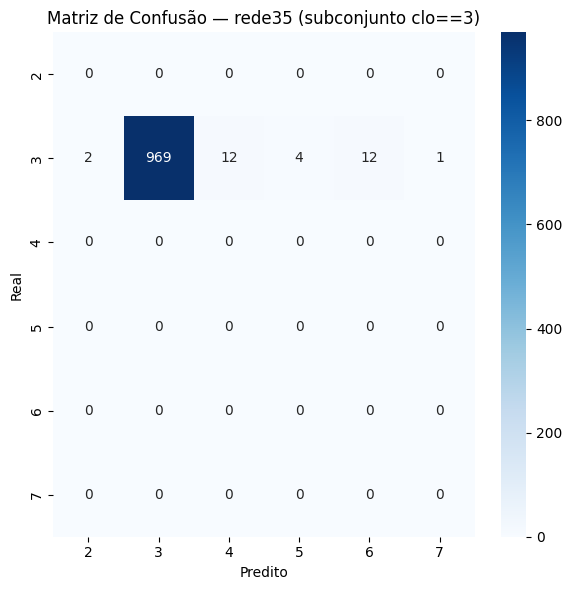

In [23]:


NC   = 30
CLASSES_ARR = np.array([1, 2, 3, 4, 5, 6, 7])

# Agora a query é o espaço W0 Binário Original!
Wk4    = wsort(carregador.W0[clo_ref == 3])
n_test = min(1000, Wk4.shape[0])
Wtes   = rede35.retrieve(Wk4[:n_test], batch_size=4096)
print(f'hopf_ts(Wswp[:{n_test}], rede35): shape {Wtes.shape}')

perf35_f = perf35.astype(np.float64)
Wtes_f   = Wtes.astype(np.float64)
a2 = (Wtes_f ** 2).sum(axis=1, keepdims=True)
b2 = (perf35_f ** 2).sum(axis=1, keepdims=True).T
idx_proto = (a2 + b2 - 2 * (Wtes_f @ perf35_f.T)).argmin(axis=1)
pred_sub  = CLASSES_ARR[idx_proto // NC]

acc_sub = (pred_sub == 3).mean()
print(f'\nAcurácia subclasse clo_ref==3: {acc_sub * 100:.2f}%')


y_true_sub = np.full(n_test, 3)
labels_sub = sorted(set(y_true_sub) | set(pred_sub))
print(classification_report(y_true_sub, pred_sub, labels=labels_sub, zero_division=0))

cm_sub = confusion_matrix(y_true_sub, pred_sub, labels=labels_sub)
fig, ax = plt.subplots(figsize=(max(6, len(labels_sub)), max(5, len(labels_sub))))
sns.heatmap(cm_sub, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_sub, yticklabels=labels_sub, ax=ax)
ax.set_xlabel('Predito'); ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão — rede35 (subconjunto clo==3)')
plt.tight_layout(); plt.show()

#### 12. Auto-imputação — Fujita → Fujita
Baseline interno: a rede treinada em Fujita recebe as próprias células Fujita.Esperamos alta taxa de reconstrução e classificação.

In [24]:
# ==============================================================================
# 3. Auto-imputação (Fujita → Fujita)
# ==============================================================================
print('\n=== Auto-imputação: Fujita → Fujita ===')
Wrecuperado_f = rede35.retrieve(carregador.W0, batch_size=2048)
print(f"Auto-imputação concluída! Shape: {Wrecuperado_f.shape}")


=== Auto-imputação: Fujita → Fujita ===
[ModernHopfieldNetwork] Recuperação concluída: (58326, 61541) (dtype=float32)
Auto-imputação concluída! Shape: (58326, 61541)


[AvaliadorHopfield] Mapeando padrões recuperados para classes (métrica: euclidiana, lotes em float32)...
[AvaliadorHopfield] Acurácia: 98.44% (n=58,326)
[AvaliadorHopfield] F1 macro=0.9616, F1 ponderado=0.9847
[AvaliadorHopfield] Taxa de reconstrução exata : 95.57%
[AvaliadorHopfield] Semelhança média ao protótipo: 0.9999
              precision    recall  f1-score   support

           1       1.00      0.99      0.99     18865
           2       0.79      0.97      0.87      1416
           3       0.98      0.97      0.98      5910
           4       0.96      0.96      0.96      2689
           5       0.99      0.93      0.96      1735
           6       0.99      0.99      0.99     24388
           7       0.99      0.98      0.98      3323

    accuracy                           0.98     58326
   macro avg       0.96      0.97      0.96     58326
weighted avg       0.99      0.98      0.98     58326

AvaliadorHopfield(
  padroes            = (210, 61541)
  classes            = [

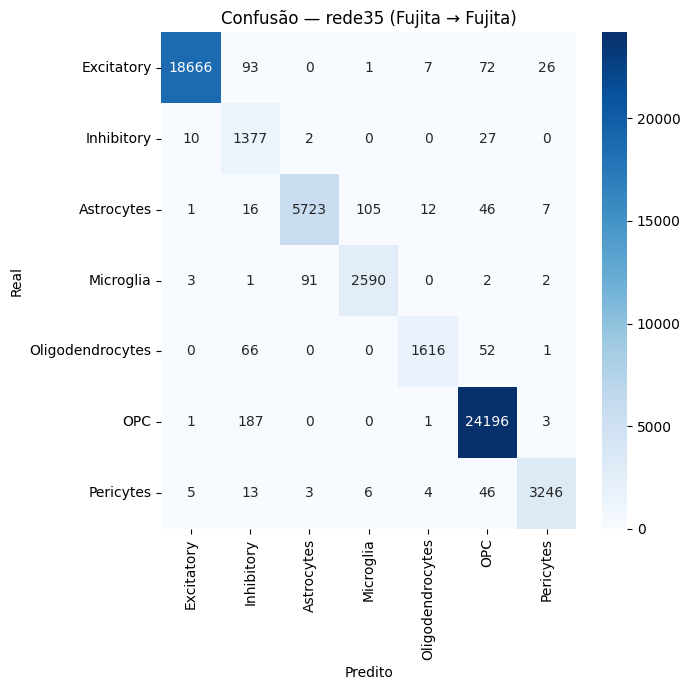

AvaliadorHopfield(
  padroes            = (210, 61541)
  classes            = [1, 2, 3, 4, 5, 6, 7]
  nc                 = 30
  metrica            = euclidiana
  acuracia           = 98.44%
  f1_macro           = 0.9616
  f1_weighted        = 0.9847
  taxa_reconstrucao  = 95.57%
  semelhanca_media   = 0.9999
)

In [25]:
avaliador_f = AvaliadorHopfield(
    padroes       = perf35,
    classes       = [1, 2, 3, 4, 5, 6, 7],
    nc            = 30,
    nomes_classes = ['Excitatory', 'Inhibitory', 'Astrocytes', 'Microglia', 'Oligodendrocytes', 'OPC', 'Pericytes'],
    meta          = meta_eval,
)

# 1. Avalia a recuperação contra os rótulos verdadeiros
avaliador_f.avaliar(Wrecuperado_f, clo_ref)
print(avaliador_f)

# 2. Plota a Matriz de Confusão
avaliador_f.plotar(titulo='Confusão — rede35 (Fujita → Fujita)')

#### 13. Imputação cross-dataset — Mathys com Sentinela Neutra 0.5
Injeta o valor sentinela 0.5 em todos os genes ausentes no Mathys durante a recuperação na rede Hopfield.
A rede realiza a atenção contínua (onde 0.5 se torna 0.0 no espaço bipolar) e reconstrói o perfil completo.

In [26]:
print('=== Imputação cross-dataset: Mathys (Sentinela Neutra 0.5) ===')

# Se rede35 ou metadados não estiverem em memória (ex: reinício de kernel), carrega do checkpoint
if 'rede35' not in globals() or 'perf35' not in globals() or 'meta_eval' not in globals():
    PATH_PT   = os.path.join(OUT_HOPFIELD, 'rede35.pt')
    PATH_META = os.path.join(OUT_HOPFIELD, 'rede35.json')
    if os.path.exists(PATH_PT) and os.path.exists(PATH_META):
        print(f"Carregando checkpoint de rede35 salvo em {PATH_PT}...")
        rede35, meta_eval, meta_json = ModernHopfieldNetwork.carregar_com_metadados(PATH_PT, PATH_META)
        perf35 = ((rede35.patterns.cpu().numpy() + 1.0) / 2.0).astype(np.float32)
    else:
        raise RuntimeError("A variável 'rede35' não está definida e o checkpoint em outputs/hopfield/ não foi encontrado. Execute as células de treino anteriores.")

# 1. Identificação dos genes ausentes no Mathys
if 'alinhador' in globals() and hasattr(alinhador, 'obter_mascara_ausentes'):
    mask_ausentes = alinhador.obter_mascara_ausentes()
elif 'adata_m' in globals() and 'presente_no_dataset' in adata_m.var:
    mask_ausentes = ~adata_m.var['presente_no_dataset'].to_numpy()
else:
    path_track = os.path.join(OUT_ALINHAMENTO, 'tracking_genes_adicionados_mathys.csv')
    if os.path.exists(path_track):
        df_tr = pd.read_csv(path_track)
        mask_ausentes = np.zeros(W_mathys.shape[1], dtype=bool)
        mask_ausentes[df_tr['posicao_coluna'].to_numpy()] = True
    else:
        mask_ausentes = np.zeros(W_mathys.shape[1], dtype=bool)

n_genes_ausentes = np.sum(mask_ausentes)
print(f"Total de genes ausentes no Mathys (Sentinela 0.5): {n_genes_ausentes:,} de {len(mask_ausentes):,} genes canônicos.")

# 2. Recuperação na rede Hopfield com injeção de 0.5 nos genes ausentes (Lotes OOM-Safe)
print("\nRecuperando padrões na Modern Hopfield Network (batch_size=2048, sentinela=0.5)...")
Wrecuperado_m = rede35.retrieve(
    queries=W_mathys,
    batch_size=2048,
    mask_sentinela_ausentes=mask_ausentes,
    fill_value=0.5
)
print(f"Recuperação concluída! Matriz reconstruída: {Wrecuperado_m.shape}")

# 3. Imputação Preservativa: Mantém valores originais observados e preenche apenas os ausentes
if hasattr(W_mathys, "toarray"):
    W_mathys_dense = W_mathys.toarray().astype(np.float32)
else:
    W_mathys_dense = np.asarray(W_mathys, dtype=np.float32)

W_mathys_imputado = W_mathys_dense.copy()
if n_genes_ausentes > 0:
    W_mathys_imputado[:, mask_ausentes] = Wrecuperado_m[:, mask_ausentes]

# Estatísticas da imputação nos genes ausentes
if n_genes_ausentes > 0:
    genes_imputados_ativos = np.sum(W_mathys_imputado[:, mask_ausentes] == 1.0)
    genes_imputados_inativos = np.sum(W_mathys_imputado[:, mask_ausentes] == 0.0)
    total_posicoes_imputadas = W_mathys_imputado.shape[0] * n_genes_ausentes
    print(f"\n--- Estatísticas da Imputação (6.289 genes ausentes) ---")
    print(f"  Posições ativadas (1.0): {genes_imputados_ativos:,} ({genes_imputados_ativos / total_posicoes_imputadas * 100:.2f}%)")
    print(f"  Posições inativadas (0.0): {genes_imputados_inativos:,} ({genes_imputados_inativos / total_posicoes_imputadas * 100:.2f}%)")

# 4. Exportação dos resultados
os.makedirs(OUT_TOP_GENES, exist_ok=True)
PATH_IMPUTADO = os.path.join(OUT_TOP_GENES, 'X_mathys_IMPUTADO_rede35.npy')
np.save(PATH_IMPUTADO, W_mathys_imputado)
print(f"\nMatriz Mathys Imputada Exportada para: {PATH_IMPUTADO}")

# 5. Avaliação do Tipo Celular Cross-Dataset
avaliador_m = AvaliadorHopfield(
    padroes = perf35,
    classes = [1, 2, 3, 4, 5, 6, 7],
    nc      = 30,
    meta    = meta_eval,
)
avaliador_m.avaliar(Wrecuperado_m, clo_alvo).plotar(titulo='Confusão — rede35 (Mathys → Fujita, Sentinela 0.5)')
print(avaliador_m)

=== Imputação cross-dataset: Mathys (Sentinela Neutra 0.5) ===
Total de genes ausentes no Mathys (Sentinela 0.5): 61,534 de 61,541 genes canônicos.

Recuperando padrões na Modern Hopfield Network (batch_size=2048, sentinela=0.5)...


TypeError: ModernHopfieldNetwork.retrieve() got an unexpected keyword argument 'mask_sentinela_ausentes'